# QCoDeS example with R&S FPL1000

[Rohde & Schwarz FPL1000](https://www.rohde-schwarz.com/us/products/test-and-measurement/benchtop-analyzers/fpl-spectrum-analyzer_63493-465280.html) is a high-performance spectrum analyzer.

In [1]:
import time
import matplotlib.pyplot as plt
from qcodes_contrib_drivers.drivers.RohdeSchwarz.FPL1000 import RohdeSchwarz_FPL1000

When connecting to instrument, use `reset=True` to initialize the instrument in a known state.

In [2]:
sa = RohdeSchwarz_FPL1000(
    name="spectrum_analyzer",
    address="TCPIP::172.27.99.89::inst0::INSTR",
    reset=True,
)

Connected to: Rohde&Schwarz FPL1026 (serial:1304.0004K26/102176, firmware:2.10SP1) in 0.34s


In [3]:
sa.print_readable_snapshot(update=True)

spectrum_analyzer:
	parameter                        value
--------------------------------------------------------------------------------
IDN                               :	{'vendor': 'Rohde&Schwarz', 'model': 'FPL...
continuous_sweep_enabled          :	True 
frequency_center                  :	1.325e+10 (Hz)
frequency_span                    :	2.65e+10 (Hz)
frequency_start                   :	0 (Hz)
frequency_stop                    :	2.65e+10 (Hz)
resolution_bandwidth              :	3e+06 (Hz)
resolution_bandwidth_auto_enabled :	True 
sweep_count                       :	0 
sweep_duration                    :	0.206 (s)
sweep_points                      :	1001 
sweep_time                        :	0.106 (s)
sweep_time_auto_enabled           :	True 
timeout                           :	5 (s)
video_bandwidth                   :	3e+06 (Hz)
video_bandwidth_auto_enabled      :	True 


To test the device, you need a separate microwave source. Suppose that a source is connected to the input and outputting a signal at 5GHz.

The frequency range of the spectrum analyzer can be set using the `frequency_center`, `frequency_span`, `frequency_start`, and `frequency_stop` parameters.

Text(0, 0.5, 'Spectrum (dBm)')

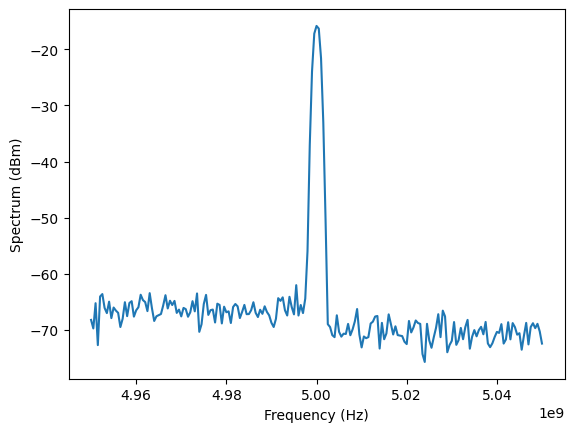

In [4]:
sa.frequency_center(5e9)
sa.frequency_span(100e6)

sa.sweep_points(201)
sa.sweep_count(5) # average over 5 sweeps

# measure the spectrum and plot it
spec = sa.spectrum()
freq = sa.frequency()

ax = plt.figure().gca()
ax.plot(freq, spec)
ax.set_xlabel(f"{sa.frequency.label} ({sa.frequency.unit})")
ax.set_ylabel(f"{sa.spectrum.label} ({sa.spectrum.unit})")

The bandwidths can be configured with the `resolution_bandwidth` and `video_bandwidth` parameters. All frequency parameters are in Hz.

In [5]:
spectra = []


for r_bw in [
    # the default value when measuring over a span of 100 MHz is 3 MHz
    10e6,
    100e3,
]:
    for v_bw in [
        10e6,
        1e3,
    ]:
        with sa.resolution_bandwidth.set_to(r_bw):
            with sa.video_bandwidth.set_to(v_bw):
                t = time.time()
                spec = sa.spectrum()
                spectra.append((r_bw, v_bw, spec))
                print(f"Resolution bandwidth {r_bw}, video bandwidth {v_bw} - measurement took {time.time() - t:.2g} s")

freq = sa.frequency()

Resolution bandwidth 10000000.0, video bandwidth 10000000.0 - measurement took 0.067 s
Resolution bandwidth 10000000.0, video bandwidth 1000.0 - measurement took 0.14 s
Resolution bandwidth 100000.0, video bandwidth 10000000.0 - measurement took 0.16 s
Resolution bandwidth 100000.0, video bandwidth 1000.0 - measurement took 3.6 s


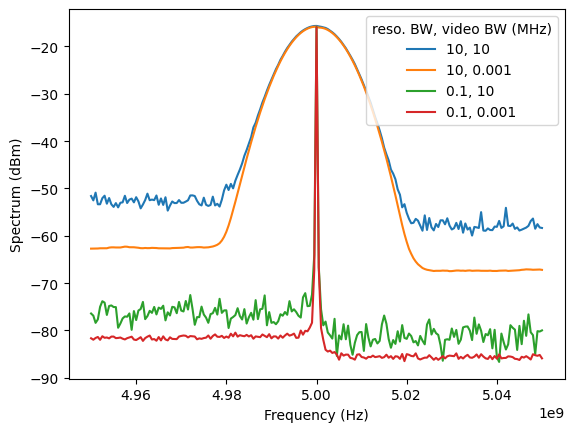

In [6]:
ax = plt.figure().gca()
for (r_bw, v_bw, spec) in spectra:
    ax.plot(freq, spec, label=f"{r_bw * 1e-6:g}, {v_bw * 1e-6:g}")

ax.set_xlabel(f"{sa.frequency.label} ({sa.frequency.unit})")
ax.set_ylabel(f"{sa.spectrum.label} ({sa.spectrum.unit})")
ax.legend(title="reso. BW, video BW (MHz)")

The bandwidths can be changed back to auto mode with the `resolution_bandwidth_auto_enabled` and `video_bandwidth_auto_enabled` parameters. When the bandwidth settings are explicitly set like above, they change to manual mode.

In [7]:
sa.resolution_bandwidth_auto_enabled()

False

In [8]:
sa.video_bandwidth_auto_enabled()

False

In [9]:
sa.resolution_bandwidth_auto_enabled(True)
sa.video_bandwidth_auto_enabled(True)